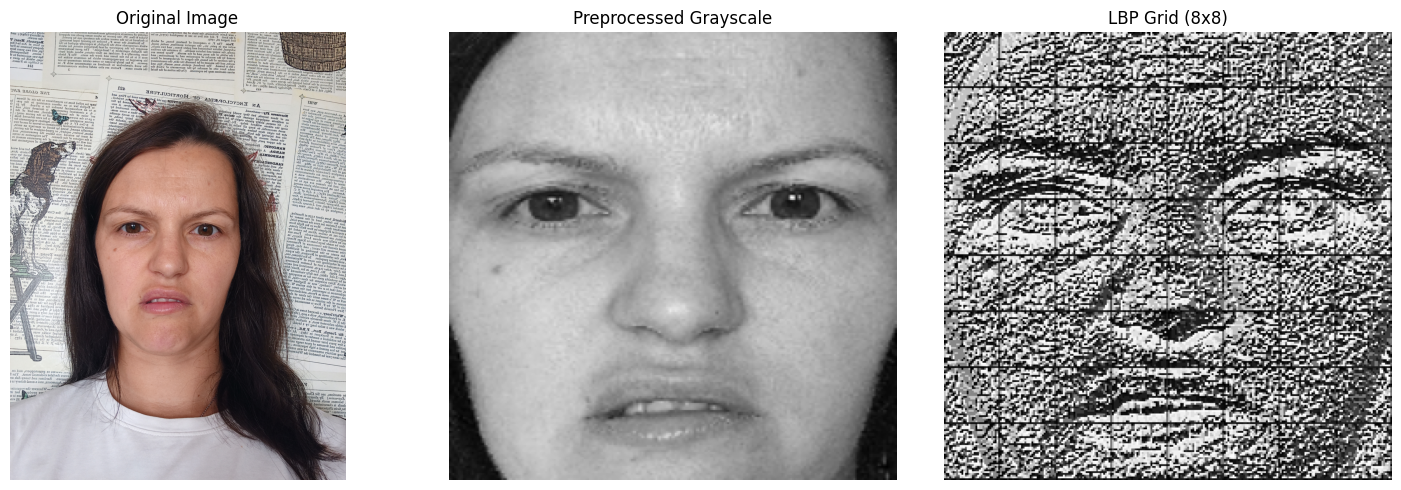

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from pathlib import Path

# Stier til original og preprosessert bilde
original_path = Path("c:/Users/nicos/lokaleprosjekter/GitHub/IT3212/data/facial_emotion_recognition/0/disgust.jpg")
preprocessed_path = Path("c:/Users/nicos/lokaleprosjekter/GitHub/IT3212/data/facial_emotion_recognition_preprocessed2/0/disgust.png")

def show_lbp_grid(original_path, preprocessed_path, grid_size=8):
    # Last inn originalbilde i farger
    original_img = cv2.imread(str(original_path))
    if original_img is None:
        print(f"Fant ikke originalbildet: {original_path}")
        return

    # Last inn preprosessert bilde i gråtoner
    img = cv2.imread(str(preprocessed_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Fant ikke preprosessert bilde: {preprocessed_path}")
        return

    # Del opp bildet i grid og beregn LBP for hver seksjon
    h, w = img.shape
    grid_h, grid_w = h // grid_size, w // grid_size
    lbp_grid = np.zeros_like(img, dtype=np.float32)
    radius = 1
    n_points = 8 * radius

    for i in range(grid_size):
        for j in range(grid_size):
            y1, y2 = i * grid_h, (i + 1) * grid_h
            x1, x2 = j * grid_w, (j + 1) * grid_w
            section = img[y1:y2, x1:x2]
            lbp_section = local_binary_pattern(section, n_points, radius, method='default')
            lbp_grid[y1:y2, x1:x2] = lbp_section

    # Vis original (farger), preprosessert (gråtoner) og grid-LBP
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(img, cmap='gray')
    plt.title('Preprocessed Grayscale')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(lbp_grid, cmap='gray')
    plt.title(f'LBP Grid ({grid_size}x{grid_size})')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Eksempel på bruk med grid_size 8
show_lbp_grid(original_path, preprocessed_path, grid_size=8)